# Web Data Science
## Week 08 - Portable Document Files (PDFs)

INFO 4871/5871. 
[Brian C. Keegan, Ph.D.](http://brianckeegan.com/)  
[Assistant Professor, Department of Information Science](https://www.colorado.edu/cmci/people/information-science/brian-c-keegan)  
University of Colorado Boulder  

Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

In [1]:
# Lets us talk to servers on the web
import requests

# For data manipulation
import pandas as pd

# We'll need to parse some strings, so we'll write some regular expressions
import re

# Dealing with files and directories
import os

# Import pyplot
import matplotlib.pyplot as plt

## Installing `PyPDF`

There is a long and frustrating history of PDF libraries in Python. There was a `pypdf` library, then it stopped being developed so someone made `pypdf2`, which then stopped being developed, and along came `pypdf3` and `pypdf4`. It appears that the development community is re-focused on `pypdf` ([development](https://github.com/py-pdf/pypdf), [docs](https://pypdf.readthedocs.io/en/stable/)) which is being actively developed again. Install `pypdf` with either:

`conda install pypdf -c conda-forge`

or

`pip install pypdf`

In [ ]:
! conda install pypdf -c conda-forge --yes

Import after intalling. 

In [3]:
import pypdf

## Context

Boulder's City Council publishes the signed minutes of its public meetings [online](https://documents.bouldercolorado.gov/WebLink/Browse.aspx?id=10888&dbid=0&repo=LF8PROD2) going back to 2000. The minutes can have ideosyncratic structures depending on the agenda of the meeting and changes in formatting across years. Generally, a meeting agenda has up to seven components: Attendees (members in attendance), open comment (people who spoke during open comment), consent agenda (core meeting items), callups and checkins (topics from board and commissions), public hearings (hearings on ordinances and other legislation).

**GOAL**: Can we retrieve the members in attendance and public speakers from each meeting's agenda?


## Open a PDF file

In [4]:
reader = pypdf.PdfReader('./BCC_2023_Minutes/City Council Minutes - 07.20.2023.pdf')

Some document-level attributes you can explore.

In [5]:
reader.metadata

{'/Author': 'Richardson,  Emily',
 '/Comments': '',
 '/Company': '',
 '/CreationDate': "D:20230913125052-06'00'",
 '/Creator': 'Acrobat PDFMaker 23 for Word',
 '/Keywords': '',
 '/ModDate': "D:20230925095620-06'00'",
 '/Producer': 'Adobe PDF Library 23.3.60',
 '/SourceModified': 'D:20230913185033',
 '/Subject': '',
 '/Title': ''}

In [6]:
len(reader.pages)

6

In [7]:
reader.page_layout

'/OneColumn'

## Extract text

(Adapted from [documentation](https://pypdf.readthedocs.io/en/stable/user/extract-text.html))

Extracting text from a PDF can be pretty tricky. In several cases there is no clear answer what the expected result should look like:

1. **Paragraphs**: Should the text of a paragraph have line breaks at the same places where the original PDF had them or should it rather be one block of text?
2. **Page numbers**: Should they be included in the extract?
3. **Headers and Footers**: Similar to page numbers - should they be extracted?
4. **Outlines**: Should outlines be extracted at all?
5. **Formatting**: If text is bold or italic, should it be included in the output?
6. **Tables**: Should the text extraction skip tables? Should it extract just the text? Should the borders be shown in some Markdown-like way or should the structure be present e.g. as an HTML table? How would you deal with merged cells?
7. **Captions**: Should image and table captions be included?
8. **Ligatures**: The Unicode symbol U+FB00 is a single symbol ﬀ for two lowercase letters ‘f’. Should that be parsed as the Unicode symbol ‘ﬀ’ or as two ASCII symbols ‘ff’?
9. **SVG images**: Should the text parts be extracted?
10. **Mathematical Formulas**: Should they be extracted? Formulas have indices, and nested fractions.
11. **Whitespace characters**: How many new lines should be extracted for 3cm of vertical whitespace? How many spaces should be extracted if there is 3cm of horizontal whitespace? When would you extract tabs and when spaces?
12. **Footnotes**: When the text of multiple pages is extracted, where should footnotes be shown?
13. **Hyperlinks and Metadata**: Should it be extracted at all? Where should it be placed in which format?
14. **Linearization**: Assume you have a floating figure in between a paragraph. Do you first finish the paragraph or do you put the figure tex

Trying this on our first page of a relatively simple PDF and we are already in a world of hurt.t in between?t in between?figure text in between?


In [8]:
page1 = reader.pages[0]

There's various metadata accessible as attributes for each page.

In [9]:
page1.rotation

0

In [10]:
page1.mediabox

RectangleObject([0.0, 0.0, 612, 792])

Get the content of a single page.

In [11]:
print(page1.extract_text())

C
ITY COUNCIL MEETING  
Council Chambers 
Thursday, July 20, 2023 
MINUTES 
1. Call to Order and Roll Call:
M
ayor Brockett  called the meeting to order at 6:00 p.m.
C
ouncil Members present :  Benjamin, Brockett, Folkerts, Joseph, Speer,
Wallach, and Winer 
  Present virtually:  Friend,  Yates 
Motion  Made By/Seconded  Vote  
Motion to AMEND  the agenda 
T
o ADD:  
•Item 7A  – Public Safe ty
around Boulder Cree kWallach  / Benjamin  Carried 9:0  
2. Open Comment:
(Public comments are a summary of actual testimony.  Full testimony i s
av
ailable on the council web page at: https://bouldercolorado.gov/city-
council > Watch Live or Archived Meetings.)
Open Comment opened  at 6:02 p.m.
 In-Person (Council Chambers):


In [12]:
page1.extract_text()

'C\nITY COUNCIL MEETING  \nCouncil Chambers \nThursday, July 20, 2023 \nMINUTES \n1. Call to Order and Roll Call:\nM\nayor Brockett  called the meeting to order at 6:00 p.m.\nC\nouncil Members present :  Benjamin, Brockett, Folkerts, Joseph, Speer,\nWallach, and Winer \n  Present virtually:  Friend,  Yates \nMotion  Made By/Seconded  Vote  \nMotion to AMEND  the agenda \nT\no ADD:  \n•Item 7A  – Public Safe ty\naround Boulder Cree kWallach  / Benjamin  Carried 9:0  \n2. Open Comment:\n(Public comments are a summary of actual testimony.  Full testimony i s\nav\nailable on the council web page at: https://bouldercolorado.gov/city-\ncouncil > Watch Live or Archived Meetings.)\nOpen Comment opened  at 6:02 p.m.\n\uf0d8 In-Person (Council Chambers):'

Try some simple cleanup.

In [13]:
text = page1.extract_text().replace('\n','')
text

'CITY COUNCIL MEETING  Council Chambers Thursday, July 20, 2023 MINUTES 1. Call to Order and Roll Call:Mayor Brockett  called the meeting to order at 6:00 p.m.Council Members present :  Benjamin, Brockett, Folkerts, Joseph, Speer,Wallach, and Winer   Present virtually:  Friend,  Yates Motion  Made By/Seconded  Vote  Motion to AMEND  the agenda To ADD:  •Item 7A  – Public Safe tyaround Boulder Cree kWallach  / Benjamin  Carried 9:0  2. Open Comment:(Public comments are a summary of actual testimony.  Full testimony i savailable on the council web page at: https://bouldercolorado.gov/city-council > Watch Live or Archived Meetings.)Open Comment opened  at 6:02 p.m.\uf0d8 In-Person (Council Chambers):'

## Loop through other files

### Measure council attendance

In [14]:
# Define a list of City Council member names
council_members = ['Benjamin','Brockett','Folkerts','Friend','Joseph','Speer','Wallach','Winer','Yates']

# Define a regex pattern that matches month name date, year
# https://stackoverflow.com/q/56065683/1574687
mdy_pattern = '((Jan(uary)?|Feb(ruary)?|Mar(ch)?|Apr(il)?|May|Jun(e)?|Jul(y)?|Aug(ust)?|Sep(tember)?|Oct(ober)?|Nov(ember)?|Dec(ember)?)\s+\d{1,2}(\s+)?,\s+\d{3,4})'

Test.

In [15]:
re.findall(mdy_pattern,text)

[('July 20, 2023', 'July', '', '', '', '', '', 'y', '', '', '', '', '', '')]

In [16]:
for member in council_members:
    print(member,member in text)

Benjamin True
Brockett True
Folkerts True
Friend True
Joseph True
Speer True
Wallach True
Winer True
Yates True


Write a loop to try to do all of it.

In [28]:
meetings = {}

for f in os.listdir('./BCC_2023_Minutes/'):
    reader = pypdf.PdfReader('./BCC_2023_Minutes/' + f)
    page1 = reader.pages[0]
    text = page1.extract_text().replace('\n','')

    date_candidates = re.findall(mdy_pattern,text)
    try:
        date = date_candidates[0][0]
        # date = pd.to_datetime(date_candidates[0][0],format='mixed')
    except IndexError:
        print(text)
    
    obj = {}

    for member in council_members:
        obj[member] = member in text

    meetings[date] = obj

In [18]:
meetings

{'May 18, 2023': {'Benjamin': False,
  'Brockett': True,
  'Folkerts': True,
  'Friend': True,
  'Joseph': True,
  'Speer': True,
  'Wallach': True,
  'Winer': True,
  'Yates': True},
 'June 15, 2023': {'Benjamin': True,
  'Brockett': True,
  'Folkerts': True,
  'Friend': True,
  'Joseph': False,
  'Speer': True,
  'Wallach': True,
  'Winer': True,
  'Yates': True},
 'March 2 , 2023': {'Benjamin': True,
  'Brockett': True,
  'Folkerts': True,
  'Friend': True,
  'Joseph': True,
  'Speer': True,
  'Wallach': False,
  'Winer': True,
  'Yates': True},
 'February 16 , 2023': {'Benjamin': False,
  'Brockett': True,
  'Folkerts': True,
  'Friend': True,
  'Joseph': True,
  'Speer': True,
  'Wallach': True,
  'Winer': True,
  'Yates': True},
 'May 4, 2023': {'Benjamin': True,
  'Brockett': True,
  'Folkerts': True,
  'Friend': True,
  'Joseph': True,
  'Speer': True,
  'Wallach': True,
  'Winer': True,
  'Yates': True},
 'April 6, 2023': {'Benjamin': False,
  'Brockett': True,
  'Folkerts': T

Turn it into a DataFrame.

In [33]:
members = pd.DataFrame(meetings).T

# Manually recode bad dates
members.index = pd.Series(members.index).replace({'June 1, 202':'June 1, 2023'})

# Cast to Timestamps
members.index = pd.to_datetime(members.index,format='mixed')

# Inspect
members.sort_index()

,Benjamin,Brockett,Folkerts,Friend,Joseph,Speer,Wallach,Winer,Yates
2023-01-05,True,True,True,True,True,True,True,True,True
2023-01-19,True,True,True,False,True,True,True,True,True
2023-01-26,True,True,True,True,True,True,True,True,False
2023-02-02,False,True,True,True,True,True,True,True,True
2023-02-09,True,True,True,True,True,True,True,True,True
2023-02-16,False,True,True,True,True,True,True,True,True
2023-03-02,True,True,True,True,True,True,False,True,True
2023-03-16,True,True,True,True,True,True,True,True,True
2023-04-06,False,True,True,True,True,True,True,True,True
2023-04-20,True,True,True,False,True,True,True,True,True


Make a visualization.

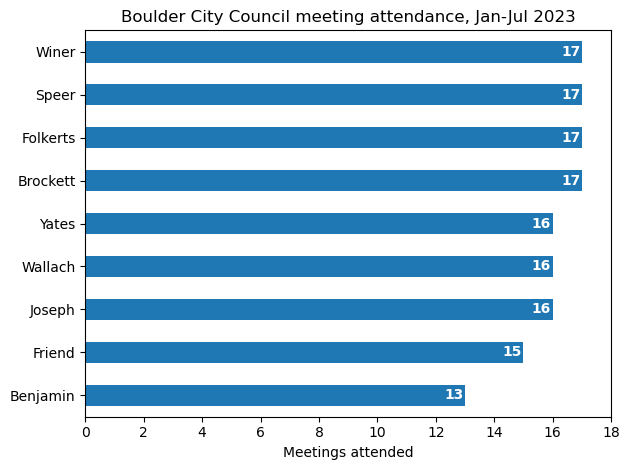

In [20]:
s = members.sum().sort_values()

f,ax = plt.subplots()

s.plot.barh(ax=ax)

ax.bar_label(ax.containers[0],label_type='edge',padding=-15,color='w',weight='bold')
ax.set_xlim((0,18))
ax.set_xlabel('Meetings attended')
ax.set_title('Boulder City Council meeting attendance, Jan-Jul 2023')

f.tight_layout()
f.savefig('attendance.png',bbox_inches='tight')

### Measure open comment frequency

In [34]:
for f in os.listdir('./BCC_2023_Minutes/'):
    reader = pypdf.PdfReader('./BCC_2023_Minutes/' + f)
    
    for i,page in enumerate(reader.pages):
        text = page.extract_text().lower()
    
        if 'open comment' in text and 'opened' in text:
            print(f,i,'opened')

City Council Minutes - 05.18.2023.pdf 1 opened
City Council Minutes - 06.15.2023.pdf 2 opened
City Council Minutes - 03.02.2023.pdf 0 opened
City Council Minutes - 02.16.2023.pdf 0 opened
City Council Minutes - 05.04.2023.pdf 1 opened
City Council Minutes - 04.06.2023.pdf 1 opened
City Council Minutes - 04.20.2023.pdf 0 opened
City Council Minutes - 01.19.2023.pdf 1 opened
City Council Minutes - 03.16.2023.pdf 1 opened
City Council Minutes - 06.01.2023.pdf 0 opened
City Council Minutes - 02.02.2023.pdf 1 opened
City Council Minutes - 07.20.2023.pdf 0 opened
City Council Minutes - 01.05.2023.pdf 1 opened


In [35]:
for f in os.listdir('./BCC_2023_Minutes/'):
    reader = pypdf.PdfReader('./BCC_2023_Minutes/' + f)
    
    for i,page in enumerate(reader.pages):
        text = page.extract_text().lower()
    
        if 'open comment' in text and 'opened' in text:
            print(reader.pages[i].extract_text())
            print(reader.pages[i+1].extract_text())

Page 2 To REMOVE:  
•Item 6A – CCRS Non -Profit
Support Program: Grant Cri teria
Review – RESCHEDULED to
June 8th Study Session
A. 25th A
nniversary of Dushanbe Teahouse Declaration  presented by
Council Member Yates
B. Old
er Americans Month Declaration  presented by Council Member
Friend
2. Open Comment:
(Public comments are a summary of actual testimony.  Full testimony is
available on the council web page at: https://bouldercolorado.gov/city-
council  > Watch Live or Archived Meetings.)
Open Comment opened at 6:19 p.m.
 In-Person (Council Chambers) :
1. Dougla
s Bendt  spoke on homeless day service center
2. Marsha Beyer  spoke on Chautauqua Park
3. Evan Ravitz  spoke on petitions
4. Robert Helterbrand  spoke on homeless day services center
5. Steve Pomerance spoke on fixing BRC title setting, comments
and challenges for ballot measures
6. Patrick O’Rourke  spoke on historic Boulder
7. Fran Mandel Sheet  spoke on central park historic district
8. Michael Xu  spoke on tennis facili

In [36]:
speakers_d = {}

for f in os.listdir('./BCC_2023_Minutes/'):
    reader = pypdf.PdfReader('./BCC_2023_Minutes/' + f)

    date = re.findall('(\d{2}\.\d{2}\.\d{4})\.pdf',f)[0]
    
    open_comment = ''
    
    for i,page in enumerate(reader.pages):
        text = page.extract_text().lower()
    
        if 'opened' in text:
            open_comment += reader.pages[i].extract_text()
            open_comment += reader.pages[i+1].extract_text()
            break
            
    pat = '\d{1,2}\.\s+(.*)\s+spoke'
    speakers_d[date] = re.findall(pat,open_comment)

In [37]:
pat = '\d{1,2}\.\s+(.*)\s+spoke'
re.findall(pat,open_comment)

['Joel Gascoigne ',
 'Chris Barge  –',
 'Evan Ravitz ',
 'Travis Hugh Culley',
 'Jess Liu',
 'R yan Harwood',
 'C laire Kelley ',
 'G ina McAfee',
 'S hari Hack ',
 'S haron Procopio',
 'R iley Mancuso',
 'Sam Jones ',
 'Aidan Reed ',
 'Rachel Daly ',
 'Eric Budd',
 'Alexis Howell',
 'Matthew Reynolds']

In [38]:
open_comment

'P age 2 to January 12th Study Session \nmeeting . \nT\no CORRECT : \n•Item 4B – To correct the\naddress of the utility easemen t\nfro\nm 3320 28th St. TO  3265\n30th St.\nA. U\npdate and discussion regarding the methamphetamine levels\ndiscovered at the main library\nN\nuria Rivera Vandermyde, City Manager,  David Farnan, Library\nDirector and Boulder County Public Health Officials provided an update\non methamphetamine levels in the main library and answered questions\nfrom Council .\nC\nhris Meschuk, Deputy City Manager and Joanna Crean, Director of\nFacilities a nd Fleet , also answered questions from Council.\n2. Open Comment:\n(Public comments are a summary of actual testimony.  Full testimony isavailable on the council web page at: https://bouldercolorado.gov/city-\ncouncil  > Watch Live or Archived Meetings.)\nOpen Comment opened at 7:09 p.m.\n\uf0d8In-Person (Council Chambers):\n1. J\nohn Neslage  spoke on s afe a ccess to Library and Boulder High\nSchool\n2. Joel Gascoigne  s

In [39]:
speakers_d

{'05.18.2023': ['Marsha Beyer ',
  'Evan Ravitz ',
  'Robert Helterbrand ',
  'Steve Pomerance',
  'Patrick O’Rourke ',
  'Fran Mandel Sheet ',
  'Michael Xu ',
  'Donald Bergal ',
  'Dan Corson',
  'Lynn Segal ',
  'Steven Bentley '],
 '06.15.2023': [],
 '03.02.2023': ['Travis Culley ',
  'Michele Rodriguez ',
  'Larry McKeogha ',
  'Evan Ravitz',
  'Tyler Hollenbach ',
  'Lynn Segal ',
  'Mark Eller '],
 '02.16.2023': ['Travis Culley ',
  'Evan Ravitz ',
  'Robert Toney',
  'Michele Rodriguez',
  'Rebecca Davies '],
 '05.04.2023': ['Daren O’Connor',
  'Samantha Weintraub -Leff',
  'Michele Rodriguez ',
  'Lupita Jaime ',
  'Deborah Foy',
  'Michael Border ',
  'Terri Brncic ',
  'Liz Janson',
  'Sarah Vollmann ',
  'Jude Landsman',
  'Emily Reynolds ',
  'Lynn Segal ',
  'Leslie Chandler ',
  'Rosie Fivian ',
  'Katie Farnan '],
 '04.06.2023': ['Evan Ravitz ',
  'Michele Rodriguez ',
  'Darren O’Connor ',
  'Travis Hugh Culley',
  'Jennifer Rhodes  spoke on safetyP age 3 10. Terri Br

## Exercises

### Exercise 01: Find another PDF
Find a reasonably simple PDF document, read it in, report out the metadata, and confirm the number of pages are as expected.

In [40]:
reader = pypdf.PdfReader('uvm_pay.pdf')

In [43]:
reader.pages[2]

{'/Contents': [IndirectObject(4, 0, 6227439184),
  IndirectObject(5, 0, 6227439184),
  IndirectObject(6, 0, 6227439184),
  IndirectObject(7, 0, 6227439184),
  IndirectObject(8, 0, 6227439184),
  IndirectObject(9, 0, 6227439184),
  IndirectObject(10, 0, 6227439184),
  IndirectObject(11, 0, 6227439184)],
 '/CropBox': [0.0, 0.0, 612, 792],
 '/MediaBox': [0.0, 0.0, 612, 792],
 '/Parent': {'/Count': 9,
  '/Kids': [IndirectObject(30751, 0, 6227439184),
   IndirectObject(1, 0, 6227439184),
   IndirectObject(3, 0, 6227439184),
   IndirectObject(13, 0, 6227439184),
   IndirectObject(15, 0, 6227439184),
   IndirectObject(17, 0, 6227439184),
   IndirectObject(19, 0, 6227439184),
   IndirectObject(21, 0, 6227439184),
   IndirectObject(23, 0, 6227439184)],
  '/Parent': {'/Count': 49,
   '/Kids': [IndirectObject(30727, 0, 6227439184),
    IndirectObject(30728, 0, 6227439184),
    IndirectObject(30729, 0, 6227439184),
    IndirectObject(30730, 0, 6227439184),
    IndirectObject(30731, 0, 6227439184),

In [57]:
text_lines = []

# For each page from 3 to 97
for page in range(2,96):

    # For each line on the page
    for line in reader.pages[page].extract_text().split('\n'):
    
        # Clean the line
        clean_line = line.strip()
    
        if '$' in line:
    
            # Break up lines on double white spaces as delimeters
            clean_list = clean_line.split('  ')
            
            # Add the data to the container
            text_lines.append(clean_list)

text_lines[:5]

[['Page 1 Abaied,Jamie L.', 'Associate Professor', '$89,559'],
 ['Abair,Steven Jed', 'Research Facilities Maint Spec', '$39,458'],
 ['Abajian,Michael John', 'Lecturer', '$55,231'],
 ['Abbott,Katharine J', 'Business/Acctng', 'Specialist', '$42,400'],
 ['Abbott,Lori M.', 'Office/Prgm Support Generalist', '$50,744']]

In [58]:
pd.DataFrame(text_lines)

,0,1,2,3
0,"Page 1 Abaied,Jamie L.",Associate Professor,"$89,559",None
1,"Abair,Steven Jed",Research Facilities Maint Spec,"$39,458",None
2,"Abajian,Michael John",Lecturer,"$55,231",None
3,"Abbott,Katharine J",Business/Acctng,Specialist,"$42,400"
4,"Abbott,Lori M.",Office/Prgm Support Generalist,"$50,744",None
...,...,...,...,...
4131,"Wilkinson,Katherine",Researcher/Analyst,"$64,375",None
4132,"Wilkinson,Lynn E.",Assistant Professor (COM),"$24,000",None
4133,"Willard -Foster,Melissa Margaret",Associate Professor,"$86,652",None
4134,"Willett,Brooke Madison",Enrollment Mgmnt Professional,"$45,493",None


### Exercise 02: Extract text
Extract the text from the first page and `print` the result. Is it well-formatted? What are some problems you see?

### Exercise 03: Implement a clean-up strategy
Use Python's string methods and regular expressions to clean up and filter the text data on the first page down to the elements you most care about.

### Exercise 04: Apply the clean-up across all the pages in the document
Put your first-page cleanup and filtering into a loop that extracts elements across all the pages in the document.

### Exercise 05: Make a visualization
Turn the data you've collected across all the pages in the document(s) into some kind of visualization.